# Validating COMPASS on three OpenNeuro datasets

This notebook runs the COMPASS multi-agent inference engine end to end on three open clinical
datasets and checks how well it recovers each dataset's clinical phenotype. It loads the pre-built,
blinded COMPASS inputs, asserts every record is well formed, runs a SUBSET (2 subjects per dataset on a
substantial representative tier) under a spend guard, visualizes the recovered phenotypes against ground
truth, and estimates the API cost and wall time of the FULL batch under a cost-optimized design.

**Cost-optimized full-batch design (section 0.5).** The naive full validation (every subject, every tier,
one premium model) was about $83 for 2155 runs. Two seeded balancing layers cut that to about $11 for about
553 runs without narrowing the question: (1) each run is routed across a verified five-provider OpenRouter
panel, balanced within every tier; (2) each subject is assigned one data-complexity tier (between-subjects),
balanced across the cohort, instead of predicting every tier per subject. Intelligence is also widened to a
diverse 200-subject cohort, already inside the $11 (the ladders were also trimmed to drop redundant tiers:
intelligence 5, psychosis 4, numeracy 3). Full detail, the panel table, and the exact numbers are
in sections 0.5 and 6.

Concurrency note: each engine run already fans out several tool/LLM calls internally
(`COMPASS_EXECUTOR_MAX_WORKERS`, default 12). Running many engine instances in an outer pool multiplies
the concurrent OpenRouter requests (outer x inner), which exhausts the connection pool / rate limit and
stalls (the provider rate-limits above about 3 to 4 concurrent large-context calls), so the subset runs one
participant at a time (outer pool = 1) with the executor fan-out bounded to 3. The full batch spreads load
across the five hosts, each rate-limited separately, so it can safely use more outer workers. Each run does
deep multi-step reasoning, so it takes a few minutes.

| Dataset | Accession | Clinical phenotype (prediction output structure) | Subset tier -> full tier |
|---|---|---|---|
| INTELLIGENCE (AOMIC-ID1000) | ds003097 | total intelligence (univariate) then 3 IST subscales (multivariate) | T4 all self-report -> T6 + brain |
| PSYCHOSIS (first-episode) | ds003944 + ds003947 | diagnosis (binary) then BPRS total (univariate) then SAPS/SANS globals (multivariate) | T2 clinical profile -> T3 + 836 EEG |
| NUMERACY (stroke) | ds006533 | approximate and precise numeracy (two dissociable univariate phenotypes) | T3 per-parcel lesion overlap (full) |

Each dataset's exact tiers and phenotype structure are documented in its `PHENOTYPE_AND_TIERS.md`.
**Models:** the SUBSET sanity runs use **deepseek/deepseek-v4-flash** (the 1M-context anchor); the FULL
batch routes across the five-provider panel in section 0.5. **How to use:** run the SETUP, PANEL/DESIGN,
REGISTRY, COHORTS and LOAD-CHECK cells once, then run each dataset's own SUBSET cell and its VISUALIZE cell
(they are separate so you can run them independently in PyCharm/Jupyter). The FULL-BATCH cells at the end
are guarded and are NOT run here; the cost-estimation cell tells you what they would cost first.

**Resumable by design:** every run is cached to system temp the moment it finishes, and a re-run skips runs
that already succeeded. So if a batch is interrupted, quit, or trips the spend guard, just run the same
cell again and it continues from exactly where it stopped, re-doing only the missing or failed runs (no
re-spend on completed ones). Nothing is written inside the repo. Pass `rerun=True` to force a clean redo.

No target value (IST/BPRS/SAPS/SANS/numeracy) is ever an input: every phenotype is inferred only from the
multimodal predictor evidence, with native scales described to the engine in each record.

In [ ]:
import os, sys, json, io, time, shutil, contextlib, warnings, tempfile, urllib.request, importlib.util
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED
warnings.filterwarnings("ignore")
# The engine parallelizes each run internally (its plan executor fans out up to COMPASS_EXECUTOR_MAX_WORKERS
# tool calls at once, embeddings up to COMPASS_EMBEDDING_MAX_WORKERS). On large tiers, 12 concurrent
# large-context calls exhaust the connection pool / hit the OpenRouter rate limit and stall, so we bound
# the internal fan-out and run one participant at a time (outer pool = 1): total concurrent provider calls
# stays near 3, which runs smoothly. For the full batch, raise these only as far as your rate limit allows.
os.environ.setdefault("COMPASS_EXECUTOR_MAX_WORKERS", "3")
os.environ.setdefault("COMPASS_EMBEDDING_MAX_WORKERS", "8")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:  # render figures inline when in a notebook; harmless no-op as a plain script
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Repo root = the folder containing src/full_stack (works from any working directory / PyCharm).
REPO = Path.cwd().resolve()
while not (REPO / "src" / "full_stack").is_dir():
    if REPO == REPO.parent:
        raise RuntimeError("Could not locate repo root (src/full_stack) above the working directory")
    REPO = REPO.parent
for p in (str(REPO), str(REPO / "validation")):
    if p not in sys.path:
        sys.path.insert(0, p)
VAL = REPO / "validation" / "datasets"

# All engine scratch (input copies, outputs, logs, cached results) lives in the SYSTEM temp dir, never
# inside the repo, so nothing here is ever committed.
SCRATCH = Path(tempfile.gettempdir()) / "compass_openneuro_validation"
(SCRATCH / "outputs").mkdir(parents=True, exist_ok=True)
(SCRATCH / "logs").mkdir(parents=True, exist_ok=True)

# DEFAULT_MODEL is the 1M-context anchor used by the cheap SUBSET sanity runs and the load-check. The
# FULL-batch design (section 0.5 and sections 6-7) does NOT use one model: it routes each run across a
# verified five-provider panel (MODEL_PANEL, defined in section 0.5) to cut cost and spread the rate limit.
DEFAULT_MODEL = "deepseek/deepseek-v4-flash"   # cheap, 1M context; the anchor for the subset run + load-check
DESIGN_SEED = 20260723                         # one seed drives BOTH randomization layers (fully reproducible)
N_PER_DATASET = 2                              # subjects per dataset for the subset sanity run
MAX_WORKERS = 1                                # OUTER engine runs: sequential. Safe for the single-provider subset;
                                               # the full batch spreads load over 5 hosts, so it can use more.
MAX_USD = 8.0                                  # hard spend guard across a run
MAX_ITERATIONS = 1                             # actor-critic depth per run

from src.full_stack.backend.config.settings import LLMBackend, get_settings
S = get_settings()
S.models.backend = LLMBackend.OPENROUTER

def set_model(model_id):
    """Point every agent role at one OpenRouter model.

    get_settings() returns a process singleton, so this changes the model the NEXT run_compass_pipeline call
    will use. We run the outer pool sequentially (MAX_WORKERS=1), so setting the model per run just before it
    starts is race-free and is how the full-batch design routes each run to its assigned provider.
    """
    S.models.public_model_name = model_id
    for role in ("orchestrator", "critic", "predictor", "integrator", "communicator", "tool"):
        setattr(S.models, f"{role}_model", model_id)

set_model(DEFAULT_MODEL)
S.paths.output_dir = SCRATCH / "outputs"
S.paths.logs_dir = SCRATCH / "logs"

import ssl
try:
    import certifi
    _SSL_CTX = ssl.create_default_context(cafile=certifi.where())   # Framework Python lacks system CAs
except Exception:
    _SSL_CTX = ssl.create_default_context()

def openrouter_usage():
    "Total OpenRouter USD used so far (None if unavailable)."
    key = S.openrouter_api_key
    if not key:
        return None
    try:
        req = urllib.request.Request("https://openrouter.ai/api/v1/credits",
                                     headers={"Authorization": f"Bearer {key}"})
        with urllib.request.urlopen(req, timeout=15, context=_SSL_CTX) as r:
            return float(json.loads(r.read().decode()).get("data", {}).get("total_usage", 0.0))
    except Exception:
        return None

assert S.openrouter_api_key, "OPENROUTER_API_KEY missing from repo-root .env"
_u = openrouter_usage()
print(f"repo:    {REPO}")
print(f"scratch: {SCRATCH}  (system temp, never committed)")
print(f"subset anchor model: {DEFAULT_MODEL}  |  workers: {MAX_WORKERS}  |  spend cap per run: +${MAX_USD:.2f}")
print(f"full-batch routing:  5-provider panel (see section 0.5)  |  design seed: {DESIGN_SEED}")
print(f"OpenRouter usage so far: {'$'+format(_u,'.4f') if _u is not None else 'unavailable'}")

## 0.5 Cost design: a five-provider panel and two balancing layers

The naive full validation (every subject, every tier, one premium model) came out near **$83** for **2155**
engine runs. Two deliberate design choices, plus one cohort change, cut that by roughly 85% without
narrowing the scientific question. They are the only cost-facing changes in this notebook, and section 6
recomputes the exact before/after.

### The verified five-provider panel (optimization 1)

Rather than route every run to one model, the full batch spreads runs across five OpenRouter providers.
Each is at or below the blended price of our anchor `deepseek/deepseek-v4-flash`, fast, and recent (newer
builds tend to give better price-for-quality). Every field below was checked live against OpenRouter's
endpoints API on 2026-07-23 (id, required host, precision, exact context, price per 1M tokens, release):

| Model (OpenRouter id) | Host | Precision | Context | In $/1M | Out $/1M | Released |
|---|---|---|---|---|---|---|
| deepseek/deepseek-v4-flash | DeepInfra | FP4 | 1,048,576 | 0.090 | 0.180 | 2026-04-24 |
| poolside/laguna-xs-2.1 | Poolside | FP8 | 262,144 | 0.060 | 0.120 | 2026-07-02 |
| nex-agi/nex-n2-mini | Nex AGI | FP8 | 262,144 | 0.025 | 0.100 | 2026-06-24 |
| qwen/qwen3.5-9b | DeepInfra | BF16 | 262,144 | 0.100 | 0.150 | 2026-03-10 |
| openai/gpt-oss-120b | DeepInfra | BF16 | 131,072 | 0.037 | 0.170 | 2025-08-05 |

Notes. Prices are the verified cheapest/host endpoint. `qwen3.5-9b` is the one model whose input list price
(0.10) sits just above the deepseek anchor (0.09); it is kept for its BF16 quality and its output (0.15) is
below deepseek's (0.18), so on our input-heavy blend it is still competitive. Context is a non-issue here:
our largest single record is about 21k tokens (psychosis T3, all 836 EEG features), far under the smallest
panel context (131,072), so every model can serve every tier with no truncation. Our workload is about 92%
input tokens (multi-agent system prompts + reasoning), so the blend that matters is roughly
`0.92*input + 0.08*output`; on that blend the panel averages about **$0.069/1M** versus **$0.097/1M** for
deepseek alone, a **0.71x** price factor. Spreading across five hosts also multiplies the safe concurrency
(each host rate-limits independently), which shortens wall time on top of the cost saving.

### The two randomization layers (both seeded by `DESIGN_SEED`)

1. **Provider balancing (optimization 1).** Each run is assigned one panel model, cycled so that within
   every tier all five providers appear about equally. Provider identity is therefore decorrelated from
   tier: a tier-vs-accuracy effect can never be an artifact of one provider, and no host is a single point
   of failure.

2. **Tier balancing across subjects (optimization 2).** The big saver. The naive design predicts the
   phenotype at **every** complexity tier **per subject** (within-subjects: N x tiers runs). We do not need
   that to answer the validation question. Instead each subject is assigned **one** tier, with tiers
   balanced across the cohort (between-subjects). We still recover the full tier-vs-accuracy dose-response
   at the cohort level, but at `1 / n_tiers` of the runs. We trade away each person's individual trajectory
   (how one subject's prediction sharpens as modalities are added) and keep the population-level answer to
   "does more data help, and by how much", which is exactly what this validation tests.

Net effect (section 6): about 2155 runs drop to about 553, and each run is about 0.71x the price, for a
full-validation estimate near **$11**. Intelligence is additionally widened to a diverse 200-subject cohort
(section 1) for statistical power, and that larger cohort is already inside the $11. The three ladders were
also trimmed to drop redundant tiers (intelligence 5, psychosis 4, numeracy 3), sharpening each tier without
changing the run count.

In [ ]:
# ---- The verified five-provider panel (every figure confirmed live on OpenRouter's endpoints API, 2026-07-23) ----
# Each model is at or below our deepseek anchor's price, fast, and recent. Prices are USD per 1M tokens.
MODEL_PANEL = [
    dict(id="deepseek/deepseek-v4-flash", host="DeepInfra", precision="FP4",  context=1_048_576, in_usd=0.090, out_usd=0.180, released="2026-04-24"),
    dict(id="poolside/laguna-xs-2.1",     host="Poolside",  precision="FP8",  context=262_144,   in_usd=0.060, out_usd=0.120, released="2026-07-02"),
    dict(id="nex-agi/nex-n2-mini",        host="Nex AGI",   precision="FP8",  context=262_144,   in_usd=0.025, out_usd=0.100, released="2026-06-24"),
    dict(id="qwen/qwen3.5-9b",            host="DeepInfra", precision="BF16", context=262_144,   in_usd=0.100, out_usd=0.150, released="2026-03-10"),
    dict(id="openai/gpt-oss-120b",        host="DeepInfra", precision="BF16", context=131_072,   in_usd=0.037, out_usd=0.170, released="2025-08-05"),
]
PANEL_BY_ID = {m["id"]: m for m in MODEL_PANEL}

# Our runs are heavily input-weighted (deepseek's own activity: ~535B prompt vs ~44B output-billed tokens,
# so ~92% input), which comes from the multi-agent system prompts + reasoning. The price that matters is
# therefore an input-weighted blend of the per-1M input/output prices, not the headline output price.
INPUT_SHARE = 0.92
def blended_price(m):
    return INPUT_SHARE * m["in_usd"] + (1.0 - INPUT_SHARE) * m["out_usd"]
_ANCHOR_BLEND = blended_price(PANEL_BY_ID[DEFAULT_MODEL])
def model_price_factor(model_id):
    "Blended price of `model_id` relative to the deepseek anchor (1.0 = same, <1 = cheaper)."
    return blended_price(PANEL_BY_ID[model_id]) / _ANCHOR_BLEND

import random
def assign_design(subject_ids, tiers, seed=DESIGN_SEED):
    """Two seeded balancing layers over a cohort. Returns [{subject, tier, model}, ...].

    Layer 2 (optimization 2): each subject gets ONE data-complexity tier, tiers balanced across subjects
    (a between-subjects ladder instead of predicting every tier per subject).
    Layer 1 (optimization 1): each subject gets ONE panel model, cycled with a per-tier offset so that
    within every tier all five providers appear about equally. This crosses tier x provider, so provider
    identity is never confounded with tier and no single provider is a bottleneck.
    Both layers are driven by the one seed, so the whole plan is reproducible.
    """
    rng = random.Random(seed)
    subs = list(subject_ids); rng.shuffle(subs)
    n_t, n_m = len(tiers), len(MODEL_PANEL)
    per_tier = {t: 0 for t in tiers}
    out = []
    for i, s in enumerate(subs):
        tier = tiers[i % n_t]                                       # opt 2: balanced tiers across subjects
        j = per_tier[tier]; per_tier[tier] += 1
        model = MODEL_PANEL[(tiers.index(tier) + j) % n_m]["id"]     # opt 1: providers staggered per tier
        out.append(dict(subject=s, tier=tier, model=model))
    return out

def design_balance_table(design, tiers):
    "tier x provider contingency table for a design (rows = tier, cols = short model id, last col = ALL)."
    short = {m["id"]: m["id"].split("/")[-1] for m in MODEL_PANEL}
    tab = pd.DataFrame(0, index=list(tiers), columns=[short[m["id"]] for m in MODEL_PANEL])
    for a in design:
        tab.loc[a["tier"], short[a["model"]]] += 1
    tab["ALL"] = tab.sum(axis=1)
    return tab

# Show the panel economics, then prove the crossing is balanced on a synthetic 300-subject x 6-tier cohort.
print("Five-provider panel (verified 2026-07-23) with input-weighted blended price and factor vs deepseek:")
for m in MODEL_PANEL:
    print(f"  {m['id']:32} {m['host']:9} {m['precision']:4} ctx={m['context']:>9,}  "
          f"in/out ${m['in_usd']:.3f}/{m['out_usd']:.3f}  blend ${blended_price(m):.4f}/1M  "
          f"factor {model_price_factor(m['id']):.2f}  ({m['released']})")
print(f"\nPanel mean price factor vs deepseek-only: {np.mean([model_price_factor(m['id']) for m in MODEL_PANEL]):.3f}  "
      f"(panel mean blend ${np.mean([blended_price(m) for m in MODEL_PANEL]):.4f}/1M vs deepseek ${_ANCHOR_BLEND:.4f}/1M)")
_demo_tiers = [f"T{k}" for k in range(6)]
_demo = assign_design([f"s{i:03d}" for i in range(300)], _demo_tiers)
print("\nBalancing self-test (300 synthetic subjects, 6 tiers): tier x provider counts stay near-uniform:")
print(design_balance_table(_demo, _demo_tiers).to_string())

## 1. Dataset registry

Each dataset contributes one or more prediction TASKS (psychosis and intelligence each have a single
hierarchical task; numeracy has two univariate tasks, one per numeracy system). For every dataset we hold
its full tier ladder, the full-complexity tier used for the subset run, the two chosen subjects, and each
task's `PredictionTaskSpec` + global instruction (native scales, imported from the dataset's own pipeline
module so the engine stays dataset-agnostic). Ground truth is loaded for scoring only, never shown to the
engine.

In [2]:
def _load(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); sys.modules[name] = m
    spec.loader.exec_module(m); return m

from src.full_stack.backend.data.models.prediction_task import (
    PredictionMode, PredictionTaskNode, PredictionTaskSpec)

DATASETS = {}   # key -> dict(label, tiers, full_tier, tasks, subjects, n_cohort, src_dir, ground_truth, diagnosis)

# ---------------- INTELLIGENCE (AOMIC-ID1000) ----------------
ist = _load(VAL / "INTELLIGENCE" / "pipeline" / "config.py", "ist_config")
ist_ann = {a["participant_id"]: a for a in
           json.load(open(VAL / "INTELLIGENCE" / "results" / "annotations.json"))["annotations"]}
_part = pd.read_csv(VAL / "INTELLIGENCE" / "dataset" / "participants.tsv", sep="\t", na_values=["n/a", "N/A", ""])
_ist_outputs = [ist.TARGET["column"]] + [s["column"] for s in ist.SUBSCALES]
_ist_stats = {c: {"mean": round(float(pd.to_numeric(_part[c], errors="coerce").mean()), 2),
                  "sd": round(float(pd.to_numeric(_part[c], errors="coerce").std(ddof=0)), 2)} for c in _ist_outputs}

def _ist_spec():
    return PredictionTaskSpec(task_id="ist_hierarchical", root=PredictionTaskNode(
        node_id="total_intelligence", display_name=ist.TARGET["label"],
        mode=PredictionMode.UNIVARIATE_REGRESSION, regression_outputs=[ist.TARGET["column"]],
        unit_by_output={ist.TARGET["column"]: "IST points"},
        children=[PredictionTaskNode(node_id="ist_subscales",
            display_name="IST subscales: fluid, memory, crystallised",
            mode=PredictionMode.MULTIVARIATE_REGRESSION, regression_outputs=[s["column"] for s in ist.SUBSCALES],
            unit_by_output={s["column"]: "IST points" for s in ist.SUBSCALES})]))

def _ist_gi():
    L = [ist.DATASET_CONTEXT, "", ist.IST_CONTEXT, "",
         "Predict these related scores on their NATIVE IST scales:"]
    t = _ist_stats[ist.TARGET["column"]]
    L.append(f"- {ist.TARGET['column']} ({ist.TARGET['label']}): overall composite. "
             f"Population reference mean={t['mean']}, sd={t['sd']} native IST points.")
    for s in ist.SUBSCALES:
        st = _ist_stats[s["column"]]
        L.append(f"- {s['column']} ({s['label']}): {s['description']} mean={st['mean']}, sd={st['sd']}.")
    L += ["", "Subscales are components of the total and move with it. No IST value for this participant is "
          "provided; infer every score only from the non-cognitive multimodal evidence. Return one numeric "
          "value per output on its native scale."]
    return "\n".join(L)

_ist_sorted = sorted(ist_ann.values(), key=lambda a: a["ground_truth"][ist.TARGET["column"]])
DATASETS["INTELLIGENCE"] = dict(
    label="AOMIC-ID1000 (ds003097): intelligence",
    tiers=["T1_demographics", "T2_personality_psychometric", "T3_identity", "T4_morphometry", "T5_connectome"],
    full_tier="T5_connectome", subset_tier="T3_identity", n_cohort=len(ist_ann),
    tasks=[dict(name="ist", spec=_ist_spec(), gi=_ist_gi(), outputs=_ist_outputs,
                target_label=ist.TARGET["label"], control_label="")],
    subjects=[_ist_sorted[0]["participant_id"], _ist_sorted[-1]["participant_id"]][:N_PER_DATASET],
    src_dir=lambda tier, subj, task: VAL / "INTELLIGENCE" / "compass_inputs" / tier / subj,
    ground_truth=lambda subj, task: ist_ann[subj]["ground_truth"],
    diagnosis=lambda subj: None)

# ---------------- PSYCHOSIS (first-episode) ----------------
sys.path.insert(0, str(VAL / "PSYCHOSIS_FIRST_EPISODE"))
from utils import compass_task as PSY
_psy_ec = json.load(open(VAL / "PSYCHOSIS_FIRST_EPISODE" / "results" / "compass" / "eval_cohort.json"))
_psy_annfile = json.load(open(VAL / "PSYCHOSIS_FIRST_EPISODE" / "results" / "compass" / "annotations.json"))
_psy_ann = {a["recording_id"]: a for a in _psy_annfile["annotations"]}
DATASETS["PSYCHOSIS"] = dict(
    label="First-episode psychosis (ds003944+ds003947)",
    tiers=["T1_demographic_socioeconomic", "T2_clinical_profile", "T3_multimodal_full", "T4_eeg_brain_only"],
    full_tier="T3_multimodal_full", subset_tier="T2_clinical_profile",
    n_cohort=_psy_annfile["n_recordings"],  # full dataset = 143 recordings
    tasks=[dict(name="psy", spec=PSY.build_task_spec(), gi=_psy_ec["global_instruction"],
                outputs=PSY.ALL_OUTPUTS, target_label=PSY.CASE_LABEL, control_label=PSY.CONTROL_LABEL)],
    subjects=[_psy_ec["psychosis"][0], _psy_ec["control"][0]][:N_PER_DATASET],  # 1 case + 1 control
    src_dir=lambda tier, subj, task: VAL / "PSYCHOSIS_FIRST_EPISODE" / "results" / "compass" / "inputs" / tier / subj,
    ground_truth=lambda subj, task: _psy_ann[subj]["ground_truth"],
    diagnosis=lambda subj: _psy_ann[subj]["diagnosis"])

# ---------------- NUMERACY (stroke) ----------------
num = _load(VAL / "NUMERACY_STROKE" / "pipeline" / "compass_task.py", "num_task")
_num_tasks, _num_gt = [], {}
for _t in num.TARGETS:
    _m, _s = num.reference_stats(_t)
    _num_tasks.append(dict(name=_t, spec=num.build_task_spec(_t), gi=num.build_global_instruction(_t, _m, _s),
                           outputs=[_t], target_label=num.TARGET_LABEL[_t], control_label=""))
    sub = json.load(open(VAL / "NUMERACY_STROKE" / "results" / f"subset_{_t}.json"))
    _num_gt[_t] = {p["participant_id"]: {_t: p["ground_truth"]} for p in sub["participants"]}
_num_blind = VAL / "NUMERACY_STROKE" / "compass_inputs"
def _num_present(subj):
    return all((_num_blind / f"{num.TARGET_SHORT[t]}_{lv}_blinded" / subj).is_dir()
               for t in num.TARGETS for lv in num.LEVELS)
DATASETS["NUMERACY"] = dict(
    label="Numeracy after stroke (ds006533)",
    tiers=num.LEVELS, full_tier="T3_lesion_fine", subset_tier="T3_lesion_fine",
    n_cohort=json.load(open(VAL / "NUMERACY_STROKE" / "results" / "annotations.json"))["n_subjects"],  # 105
    tasks=_num_tasks,
    subjects=[s for s in sorted(_num_gt[num.TARGETS[0]]) if _num_present(s)][:N_PER_DATASET],
    src_dir=lambda tier, subj, task: _num_blind / f"{num.TARGET_SHORT[task]}_{tier}_blinded" / subj,
    ground_truth=lambda subj, task: _num_gt[task][subj],
    diagnosis=lambda subj: None)

for k, d in DATASETS.items():
    n = len(d["subjects"]) * len(d["tasks"])
    print(f"{k:12} subset tier={d['subset_tier']:26} ({n} runs) | full tier={d['full_tier']:20} "
          f"| ladder={len(d['tiers'])} tiers, cohort~{d['n_cohort']} | subjects={d['subjects']}")

INTELLIGENCE subset tier=T4_identity                (2 runs) | full tier=T6_connectome        | ladder=6 tiers, cohort~100 | subjects=['eval-0005', 'eval-0066']
PSYCHOSIS    subset tier=T2_clinical_profile        (2 runs) | full tier=T3_multimodal_full   | ladder=5 tiers, cohort~143 | subjects=['ds003947_sub-2477A', 'ds003944_sub-1448']
NUMERACY     subset tier=T3_lesion_coarse           (4 runs) | full tier=T3_lesion_fine       | ladder=4 tiers, cohort~105 | subjects=['eval-0001', 'eval-0002']


In [ ]:
# ---- Full-validation cohorts (used by the section 6 estimate and the guarded section 7 runs) ----
# The SUBSET cells (sections 3-5) run d["subjects"] (2 built subjects) on one tier with DEFAULT_MODEL. The
# FULL batch instead runs a between-subjects design over d["full_cohort"]: one tier + one provider per
# subject, assigned by assign_design(). We attach that cohort and a full-cohort ground-truth resolver here.

# INTELLIGENCE: widen beyond the annotated 100 to a diverse 200-subject cohort spanning the WHOLE IST range.
# 926 of the 928 AOMIC participants have complete IST scores; we select 200 by seeded stratified sampling
# across the sorted IST distribution, which guarantees even low-to-high coverage (a diverse intelligence
# range), not a lucky draw. Ground truth is the participants.tsv IST scores. (Blinded inputs are built for
# 100 today under the evaluation split; running all 200 means building inputs for the rest first.)
IST_COHORT_CAP = 200
_ist_scored = (_part.assign(_ist=pd.to_numeric(_part["IST_intelligence_total"], errors="coerce"))
                    .dropna(subset=["_ist"]).sort_values("_ist"))
def _diverse_by_range(df_sorted, n, seed):
    ids = df_sorted["participant_id"].tolist()
    if len(ids) <= n:
        return ids
    rng = np.random.default_rng(seed)
    edges = np.linspace(0, len(ids), n + 1).astype(int)            # n equal-mass strata across the IST range
    return [ids[int(rng.integers(edges[k], max(edges[k] + 1, edges[k + 1])))] for k in range(n)]
_ist_cohort = _diverse_by_range(_ist_scored, IST_COHORT_CAP, DESIGN_SEED)
_ist_cohort_set = set(_ist_cohort)
_ist_gt_full = {r.participant_id: {c: float(getattr(r, c)) for c in _ist_outputs}
                for r in _ist_scored.itertuples() if r.participant_id in _ist_cohort_set}
DATASETS["INTELLIGENCE"].update(
    full_cohort=_ist_cohort, n_cohort=len(_ist_cohort),
    full_gt=lambda subj, task: _ist_gt_full[subj], full_diag=lambda subj: None)

# PSYCHOSIS: the full 143 recordings already carry ground truth + diagnosis in annotations.json.
DATASETS["PSYCHOSIS"].update(
    full_cohort=list(_psy_ann.keys()), n_cohort=len(_psy_ann),
    full_gt=lambda subj, task: _psy_ann[subj]["ground_truth"],
    full_diag=lambda subj: _psy_ann[subj]["diagnosis"])

# NUMERACY: the full 105 subjects carry both-phenotype ground truth in annotations.json.
_num_annfile = json.load(open(VAL / "NUMERACY_STROKE" / "results" / "annotations.json"))
_num_gt_full = {a["participant_id"]: a["ground_truth"] for a in _num_annfile["annotations"]}
DATASETS["NUMERACY"].update(
    full_cohort=[a["participant_id"] for a in _num_annfile["annotations"]], n_cohort=len(_num_gt_full),
    full_gt=lambda subj, task: {task: _num_gt_full[subj][task]}, full_diag=lambda subj: None)

# Report each full cohort and how many already have blinded inputs built on disk (runnable now vs to-build).
def _built_at(dkey, tier):
    d = DATASETS[dkey]
    return sum(1 for s in d["full_cohort"] if d["src_dir"](tier, s, d["tasks"][0]["name"]).is_dir())
print("Full-validation cohorts (between-subjects design => one tier per subject):")
for k, d in DATASETS.items():
    old_runs = d["n_cohort"] * len(d["tasks"]) * len(d["tiers"])
    new_runs = d["n_cohort"] * len(d["tasks"])
    print(f"  {k:12} n_cohort={d['n_cohort']:>3} | tiers={len(d['tiers'])} | tasks={len(d['tasks'])} | "
          f"runs {old_runs:>4} -> {new_runs:>3} | built@subset_tier={_built_at(k, d['subset_tier'])}")

## 1.1 The data-complexity ladders and the phenotype targets

Every run predicts a dataset's clinical phenotype from a blinded record; the only thing that changes up a
ladder is HOW MUCH evidence the engine sees. The subset below runs one substantial tier per dataset (bold).
The ladders were trimmed on 2026-07-23 to remove redundant tiers (see the notes under each table).

**Data-complexity tier ladders** (each tier adds a modality; the target is never an input)

| INTELLIGENCE (AOMIC-ID1000), 5 tiers | adds |
|---|---|
| T1_demographics | age, sex, handedness, BMI, education, socio-economic status |
| T2_personality_psychometric | + NEO-FFI Big Five, BIS/BAS reinforcement sensitivity, STAI trait anxiety |
| **T3_identity (subset)** | + sexual/gender identity, religiosity (all self-report) |
| T4_morphometry | + FreeSurfer brain morphometry |
| T5_connectome (full) | + movie-fMRI functional connectome |

Personality and the motivation/affect psychometrics are merged into one self-report tier (they are all
self-report questionnaires); the two brain tiers stay separate (structural vs functional).

| PSYCHOSIS (ds003944 + ds003947), 4 tiers | adds |
|---|---|
| T1_demographic_socioeconomic | demographics + Hollingshead socio-economic status |
| **T2_clinical_profile (subset)** | + MATRICS cognition, WASI IQ, GAF/SFS observed functioning |
| T3_multimodal_full (full) | + all 836 resting-EEG features |
| T4_eeg_brain_only | 79-feature psychosis-signature resting EEG only (brain-only) |

The two former EEG-only tiers (29-feature lean, full 836 rich) are collapsed into one brain-only tier
carrying a curated 79-feature psychosis signature (spectral slowing and alpha deficit, alpha-peak slowing,
aperiodic 1/f, signal complexity, microstate C/D, connectivity): richer than the old lean, but not the full
836, which was about 95% redundant with the multimodal ceiling T3.

| NUMERACY (ds006533), 3 tiers | adds |
|---|---|
| T1_demographics | age, education, imaging modality |
| T2_aphasia | + WAB-R aphasia quotient, whole-brain lesion load |
| **T3_lesion_fine (subset, full)** | + per-parcel lesion overlap (194 features) |

Only the high-resolution per-parcel lesion tier is kept; the coarse network-level tier was the same
modality at lower resolution (the fine parcels aggregate to those networks), so it was redundant.

**Complete phenotype target structure** (the hierarchy the engine predicts per run)

```text
INTELLIGENCE  (hierarchical regression)
  total_intelligence          univariate     IST_intelligence_total          native IST 2000-R points
    ist_subscales             multivariate   IST_fluid, IST_memory, IST_crystallised

PSYCHOSIS     (mixed-type hierarchy)
  diagnosis                   binary         Control vs First-Episode Psychosis
    global_severity           univariate     BPRS 19-item total              19-133
      positive_symptoms       multivariate   4 SAPS global ratings           0-5 each
      negative_symptoms       multivariate   5 SANS global ratings           0-5 each

NUMERACY      (two dissociable univariate phenotypes, predicted separately)
  approximate_numeracy        univariate     non-symbolic Approximate Number System   population Z-score
  precise_numeracy            univariate     precise symbolic numeracy                population Z-score
```

The engine is told each native scale (and, for numeracy, that the transformed tier is standardized) in the
per-dataset global instruction and in each record's text, so the numbers are interpretable. Full per-dataset
detail is in each dataset's `PHENOTYPE_AND_TIERS.md`.

## 2. Engine run helpers and load-check

`run_job` copies a record's four files into a uniquely named participant directory (in system temp) so
workers never collide on the engine's per-participant output path, runs the full COMPASS pipeline, and
harvests the prediction from the in-memory result. Two batch entry points share one resumable, spend-guarded
runner (`_run_batch`): `run_dataset` runs the SUBSET (the 2 built subjects on a tier, all on the deepseek
anchor), and `run_full_design` runs the FULL batch under the section 0.5 design (`build_design_jobs` assigns
one tier and one balanced provider per subject). Each run is routed to its assigned model by `set_model`
just before it starts (safe because the outer pool is sequential), and every result row records which
provider served it. The load-check then asserts every subset record parses through the engine's own
`DataLoader` with a valid ontology and no target leakage.

In [ ]:
def harvest(result):
    "Generic: pull the diagnosis label/probs and every regression value from any hierarchy."
    pred = (result.get("internal_context") or {}).get("prediction")
    root = getattr(pred, "root_prediction", None)
    out = {"label": None, "probs": None, "regression": {}}
    if root is None:
        return out
    for node in [root] + (root.walk() if hasattr(root, "walk") else []):
        cls = getattr(node, "classification", None)
        if cls is not None and out["label"] is None:
            lab = getattr(cls, "predicted_label", None) or getattr(cls, "label", None)
            pr = getattr(cls, "class_probabilities", None) or getattr(cls, "probabilities", None)
            out["label"] = None if lab is None else str(lab)
            if isinstance(pr, dict):
                out["probs"] = {str(k): float(v) for k, v in pr.items()}
        reg = getattr(node, "regression", None)
        for k, v in (getattr(reg, "values", None) or {}).items():
            try:
                out["regression"][str(k)] = float(v)
            except (TypeError, ValueError):
                pass
    return out

# The kept fields on every result row (adds "model" so the full-batch routing is recorded per run).
KEEP = ("dataset", "task", "tier", "subject", "model", "outputs", "ground_truth", "diagnosis")

def build_jobs(dkey, tiers):
    "SUBSET jobs: the 2 built subjects x the requested tiers, all on DEFAULT_MODEL (single-provider sanity)."
    d = DATASETS[dkey]; jobs = []
    for task in d["tasks"]:
        for subj in d["subjects"]:
            for tier in tiers:
                src = d["src_dir"](tier, subj, task["name"])
                jobs.append(dict(dataset=dkey, task=task["name"], tier=tier, subject=subj, model=DEFAULT_MODEL,
                                 src_dir=src, spec=task["spec"], gi=task["gi"], outputs=task["outputs"],
                                 target_label=task["target_label"], control_label=task["control_label"],
                                 ground_truth=d["ground_truth"](subj, task["name"]), diagnosis=d["diagnosis"](subj),
                                 uid=f"{dkey}__{task['name']}__{tier}__{subj}".replace("/", "-")))
    return jobs

def build_design_jobs(dkey, seed=DESIGN_SEED):
    "FULL-batch jobs from the seeded design: one tier + one provider per subject (both optimizations)."
    d = DATASETS[dkey]; jobs = []
    for a in assign_design(d["full_cohort"], d["tiers"], seed):
        subj, tier, model = a["subject"], a["tier"], a["model"]
        for task in d["tasks"]:                                   # numeracy runs both phenotypes at the assigned tier
            src = d["src_dir"](tier, subj, task["name"])
            jobs.append(dict(dataset=dkey, task=task["name"], tier=tier, subject=subj, model=model,
                             src_dir=src, spec=task["spec"], gi=task["gi"], outputs=task["outputs"],
                             target_label=task["target_label"], control_label=task["control_label"],
                             ground_truth=d["full_gt"](subj, task["name"]), diagnosis=d["full_diag"](subj),
                             uid=f"{dkey}__{task['name']}__{tier}__{subj}__{model}".replace("/", "-")))
    return jobs

RUN_TIMEOUT_S = 1500   # watchdog: a single run may not exceed this (keeps the batch from ever hanging)

def _run_one(job):
    from main import run_compass_pipeline
    set_model(job.get("model") or DEFAULT_MODEL)                  # route THIS run to its assigned provider
    pdir = SCRATCH / "inputs" / job["uid"]; pdir.mkdir(parents=True, exist_ok=True)
    for f in ("data_overview.json", "hierarchical_deviation_map.json", "multimodal_data.json", "non_numerical_data.txt"):
        shutil.copy(job["src_dir"] / f, pdir / f)
    buf, t0 = io.StringIO(), time.time()
    try:
        with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
            res = run_compass_pipeline(participant_dir=pdir, target_condition=job["target_label"],
                control_condition=job["control_label"], prediction_task_spec=job["spec"],
                agent_instructions={"global": job["gi"]}, max_iterations=MAX_ITERATIONS,
                verbose=False, interactive_ui=False)
        return {**{k: job[k] for k in KEEP}, "prediction": harvest(res),
                "seconds": round(time.time() - t0, 1), "ok": True}
    except Exception as e:
        return {**{k: job[k] for k in KEEP}, "error": f"{type(e).__name__}: {e}",
                "log_tail": buf.getvalue()[-800:], "ok": False}
    finally:
        shutil.rmtree(pdir, ignore_errors=True)

def run_job(job):
    "Run one participant with a hard watchdog so a stuck provider call never blocks the batch."
    import threading
    box = {}
    th = threading.Thread(target=lambda: box.__setitem__("r", _run_one(job)), daemon=True)
    th.start(); th.join(timeout=RUN_TIMEOUT_S)
    if th.is_alive():
        return {**{k: job[k] for k in KEEP}, "error": f"timeout after {RUN_TIMEOUT_S}s", "ok": False}
    return box["r"]

def _tag(r):
    if not r.get("ok"):
        return "ERROR " + r.get("error", "")[:56]
    p = r["prediction"]
    if p["label"] is not None:
        pr = max(p["probs"].values()) if p.get("probs") else None
        return f"dx={p['label'][:20]}" + (f" p={pr:.2f}" if pr else "")
    o = r["outputs"][0]; gt = (r["ground_truth"] or {}).get(o)
    return f"{o.split('__')[-1][:16]}: pred={p['regression'].get(o)}, true={gt}"

def _run_batch(dkey, jobs, label, rerun=False):
    """Run a prepared list of jobs, RESUMABLE and spend-guarded, routing each run to its own model.

    Every finished run is written to results_<dataset>_<label>.json immediately and runs that already
    succeeded (keyed by subject/task/tier) are skipped, so an interrupted or spend-capped batch simply
    continues where it stopped on a re-run. Pass rerun=True to force a clean redo.
    """
    cache = SCRATCH / f"results_{dkey}_{label}.json"
    prior = [] if rerun else (json.loads(cache.read_text()) if cache.exists() else [])
    rows = [r for r in prior if r.get("ok")]                      # keep successes, retry failures
    done = {(r["subject"], r["task"], r["tier"]) for r in rows}
    todo = [j for j in jobs if (j["subject"], j["task"], j["tier"]) not in done]
    print(f"[{dkey}] {label}: {len(jobs)} total runs | {len(rows)} already cached ok | {len(todo)} to run now", flush=True)
    if not todo:
        print(f"[{dkey}] nothing to do; using cached results (set rerun=True to redo).")
        return rows
    u0 = openrouter_usage() or 0.0
    print(f"[{dkey}] running {MAX_WORKERS} worker(s), spend cap +${MAX_USD:.2f}", flush=True)
    ex = ThreadPoolExecutor(max_workers=MAX_WORKERS)
    it = iter(todo); pending = {}; stop = False; new_ok = n = 0
    def submit():
        try:
            j = next(it)
        except StopIteration:
            return
        pending[ex.submit(run_job, j)] = j
    for _ in range(min(MAX_WORKERS, len(todo))):
        submit()
    try:
        while pending and not stop:
            fin, _ = wait(set(pending), return_when=FIRST_COMPLETED)
            for f in fin:
                pending.pop(f); n += 1; r = f.result(); rows.append(r)
                new_ok += 1 if r.get("ok") else 0
                cache.write_text(json.dumps(rows, indent=2, default=str))   # persist after EACH run
                print(f"  [{n:>3}/{len(todo)}] {r['tier']:26} {str(r['subject'])[:18]:18} "
                      f"{str(r.get('model','')).split('/')[-1][:15]:15} {r.get('seconds','?')!s:>5}s  {_tag(r)}", flush=True)
                u = openrouter_usage()
                if u is not None and u - u0 >= MAX_USD:
                    print(f"  [spend guard hit +${u-u0:.2f}; stopped. Progress saved; re-run this cell to continue.]")
                    stop = True; break
                submit()
    finally:
        for f in pending:
            f.cancel()
        ex.shutdown(wait=True)
    spent = (openrouter_usage() or u0) - u0
    ok = [r for r in rows if r.get("ok")]
    (SCRATCH / f"results_{dkey}_{label}_meta.json").write_text(json.dumps({
        "n_runs": len(rows), "n_ok": len(ok),
        "avg_seconds": round(float(np.mean([r["seconds"] for r in ok])), 1) if ok else None,
        "cost_per_run": round(spent / new_ok, 5) if new_ok else None,
        "spent_usd_this_run": round(spent, 5)}, indent=2))
    print(f"[{dkey}] {label}: {len(ok)}/{len(rows)} ok overall | this run spent ${spent:.4f} over {new_ok} new run(s)", flush=True)
    return rows

def run_dataset(dkey, tiers, rerun=False, label="subset"):
    "SUBSET runner (unchanged interface): the 2 built subjects on `tiers`, all on DEFAULT_MODEL."
    return _run_batch(dkey, build_jobs(dkey, tiers), label, rerun)

def run_full_design(dkey, rerun=False, label="full"):
    "FULL-batch runner: the seeded between-subjects + 5-provider design; skips subjects whose inputs are not built yet."
    jobs = build_design_jobs(dkey)
    runnable = [j for j in jobs if j["src_dir"].is_dir()]
    missing = len(jobs) - len(runnable)
    if missing:
        print(f"[{dkey}] {missing}/{len(jobs)} design runs have no blinded inputs on disk yet "
              f"(build them via the dataset pipeline); running the {len(runnable)} that exist.")
    return _run_batch(dkey, runnable, label, rerun)

# Load-check every subset record through the engine DataLoader (cheap, no spend).
from src.full_stack.backend.utils.core.data_loader import DataLoader
dl = DataLoader(); checked = 0
for dkey, d in DATASETS.items():
    for job in build_jobs(dkey, [d["subset_tier"]]):
        assert job["src_dir"].is_dir(), f"missing input dir: {job['src_dir']}"
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
            data = dl.load(job["src_dir"])
        cov = data.data_overview
        assert cov.domain_coverage and cov.total_tokens and cov.total_tokens > 0, f"bad overview: {job['src_dir']}"
        blob = json.dumps(getattr(data.multimodal_data, "raw", None) or getattr(data.multimodal_data, "__dict__", {}), default=str)
        for tok in job["outputs"]:
            assert tok not in blob, f"target {tok} leaked into inputs: {job['src_dir']}"
        checked += 1
def _reg_frame(rows):
    "Tidy (subject, tier, output, predicted, truth, error) frame from a dataset's results."
    out = []
    for r in rows:
        if not r.get("ok"):
            continue
        for o in r["outputs"]:
            pred = r["prediction"]["regression"].get(o); gt = (r["ground_truth"] or {}).get(o)
            out.append(dict(subject=r["subject"], tier=r["tier"], output=o, predicted=pred, truth=gt,
                            error=None if (pred is None or gt is None) else pred - gt))
    return pd.DataFrame(out)

RUN = {}   # dataset key -> subset results (filled by the per-dataset cells below)
print(f"OK: {checked} full-tier subset records load cleanly through the engine, 0 target leaks.")

## 3. INTELLIGENCE subset run (AOMIC ID1000, OpenNeuro ds003097)

Runs the 2 diverse subjects (lowest and highest IST) on the substantial all-self-report tier, on the
deepseek anchor. Press this cell to run it yourself; it caches, so a re-run does not re-spend (pass
`rerun=True` to force). The engine predicts total IST intelligence and, beneath it, the three subscales.

**INPUT - data-complexity ladder** (5 tiers; each adds a modality; target is never an input; subset in bold)

| tier | adds | ~tokens |
|---|---|---|
| T1_demographics | age, sex, handedness, BMI, education, SES | 45 |
| T2_personality_psychometric | + NEO-FFI Big Five, BIS/BAS, STAI (all self-report) | 121 |
| **T3_identity (subset)** | + sexual/gender identity, religiosity (all self-report) | 180 |
| T4_morphometry | + FreeSurfer brain morphometry | 3063 |
| T5_connectome | + movie-fMRI functional connectome | 3473 |

**OUTPUT - target phenotype** (hierarchical regression, native IST 2000-R points)
- `total_intelligence` (univariate): `IST_intelligence_total`
  - `ist_subscales` (multivariate): `IST_fluid`, `IST_memory`, `IST_crystallised`

**Linguistic representation:** the global instruction states the cohort context (AOMIC ID1000, 928 healthy
Dutch young adults, ds003097, normal intelligence range) and the IST native-scale meaning, so the engine
knows the population and the scale it predicts on. Predictors are grouped under a semantic ontology
(self-report constructs plus a BRAIN domain for the imaging tiers).

In [4]:
RUN["INTELLIGENCE"] = run_dataset("INTELLIGENCE", [DATASETS["INTELLIGENCE"]["subset_tier"]], rerun=False)

[INTELLIGENCE] subset: 2 total runs | 2 already cached ok | 0 to run now


[INTELLIGENCE] nothing to do; using cached results (set rerun=True to redo).


### 3.1 Recovered intelligence vs ground truth

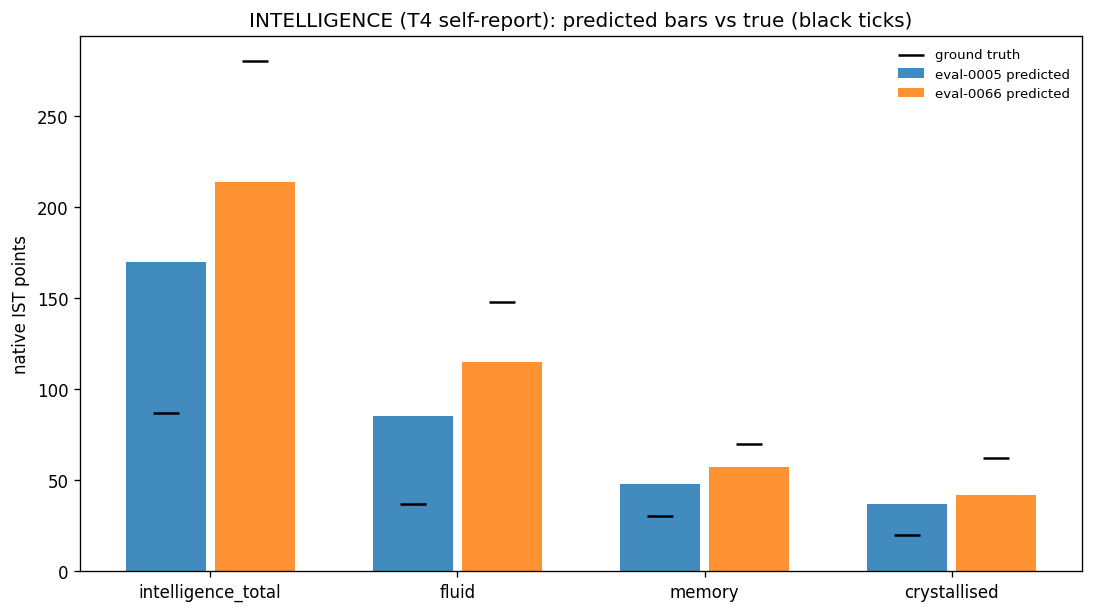

  subject                 output  predicted  truth  error
eval-0005 IST_intelligence_total      170.0   87.0   83.0
eval-0005              IST_fluid       85.0   37.0   48.0
eval-0005             IST_memory       48.0   30.0   18.0
eval-0005       IST_crystallised       37.0   20.0   17.0
eval-0066 IST_intelligence_total      214.0  280.0  -66.0
eval-0066              IST_fluid      115.0  148.0  -33.0
eval-0066             IST_memory       57.0   70.0  -13.0
eval-0066       IST_crystallised       42.0   62.0  -20.0


In [5]:
df = _reg_frame(RUN.get("INTELLIGENCE", []))
if not df.empty:
    outs = ["IST_intelligence_total", "IST_fluid", "IST_memory", "IST_crystallised"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)
    x = np.arange(len(outs)); w = 0.36
    for i, subj in enumerate(sorted(df["subject"].unique())):
        s = df[df["subject"] == subj].set_index("output")
        pr = [s.loc[o, "predicted"] if o in s.index else np.nan for o in outs]
        tr = [s.loc[o, "truth"] if o in s.index else np.nan for o in outs]
        ax.bar(x + (i - 0.5) * w, pr, w * 0.9, label=f"{subj} predicted", alpha=0.85)
        ax.scatter(x + (i - 0.5) * w, tr, color="k", zorder=3, marker="_", s=260,
                   label="ground truth" if i == 0 else None)
    ax.set_xticks(x); ax.set_xticklabels([o.replace("IST_", "") for o in outs])
    ax.set_ylabel("native IST points"); ax.set_title("INTELLIGENCE (T4 self-report): predicted bars vs true (black ticks)")
    ax.legend(fontsize=8, frameon=False); plt.show()
    print(df[["subject", "output", "predicted", "truth", "error"]].round(1).to_string(index=False))
else:
    print("Run the INTELLIGENCE subset cell above first.")

## 4. PSYCHOSIS subset run (first-episode psychosis, OpenNeuro ds003944 + ds003947)

Runs 1 case + 1 control on the clinical-profile tier, on the deepseek anchor. Press to run it yourself; it
caches (pass `rerun=True` to force). NOTE: the predictor inputs were rebuilt on 2026-07-23 (restructured
Global Functioning ontology; the two EEG-only tiers collapsed into one brain-only tier), so to see engine
results on the NEW structure press this cell with `rerun=True`; the displayed output is the prior run.

**INPUT - data-complexity ladder** (4 tiers; subset in bold)

| tier | evidence | ~tokens |
|---|---|---|
| T1_demographic_socioeconomic | demographics + Hollingshead SES | 70 |
| **T2_clinical_profile (subset)** | + MATRICS cognition, WASI IQ, GAF/SFS observed functioning | 1185 |
| T3_multimodal_full (full) | + all 836 resting-EEG features (multimodal ceiling) | 21074 |
| T4_eeg_brain_only | 79-feature psychosis-signature resting EEG only (brain-only) | 1468 |

The brain-only tier is a curated psychosis signature (spectral slowing + alpha deficit, alpha-peak slowing,
aperiodic 1/f, signal complexity, microstate C/D, connectivity): richer than the old 29-feature lean, far
below the full 836 (which was redundant with T3).

**INPUT - predictor ontology** (3 primary domains)
- Resting EEG (836 leaves): 8 EEG feature families
- Demographics and Socio-economic Status (8 leaves)
- Global Functioning (91 leaves): MATRICS cognition, WASI intelligence, GAF ratings and the Social
  Functioning Scale, all as secondary siblings under one umbrella

**OUTPUT - target phenotype** (mixed-type hierarchy)
- `diagnosis` (binary): Control vs First-Episode Psychosis
  - `global_severity` (univariate): BPRS 19-item total (19-133)
    - `positive_symptoms` (multivariate): 4 SAPS global ratings (0-5 each)
    - `negative_symptoms` (multivariate): 5 SANS global ratings (0-5 each)

**Linguistic representation:** the global instruction states the cohort (ds003944 + ds003947, first-episode
psychosis plus matched controls, resting EEG) and each native clinical scale with its reference mean/sd.

In [6]:
RUN["PSYCHOSIS"] = run_dataset("PSYCHOSIS", [DATASETS["PSYCHOSIS"]["subset_tier"]], rerun=False)

[PSYCHOSIS] subset: 2 total runs | 2 already cached ok | 0 to run now


[PSYCHOSIS] nothing to do; using cached results (set rerun=True to redo).


### 4.1 Recovered diagnosis and symptom severity

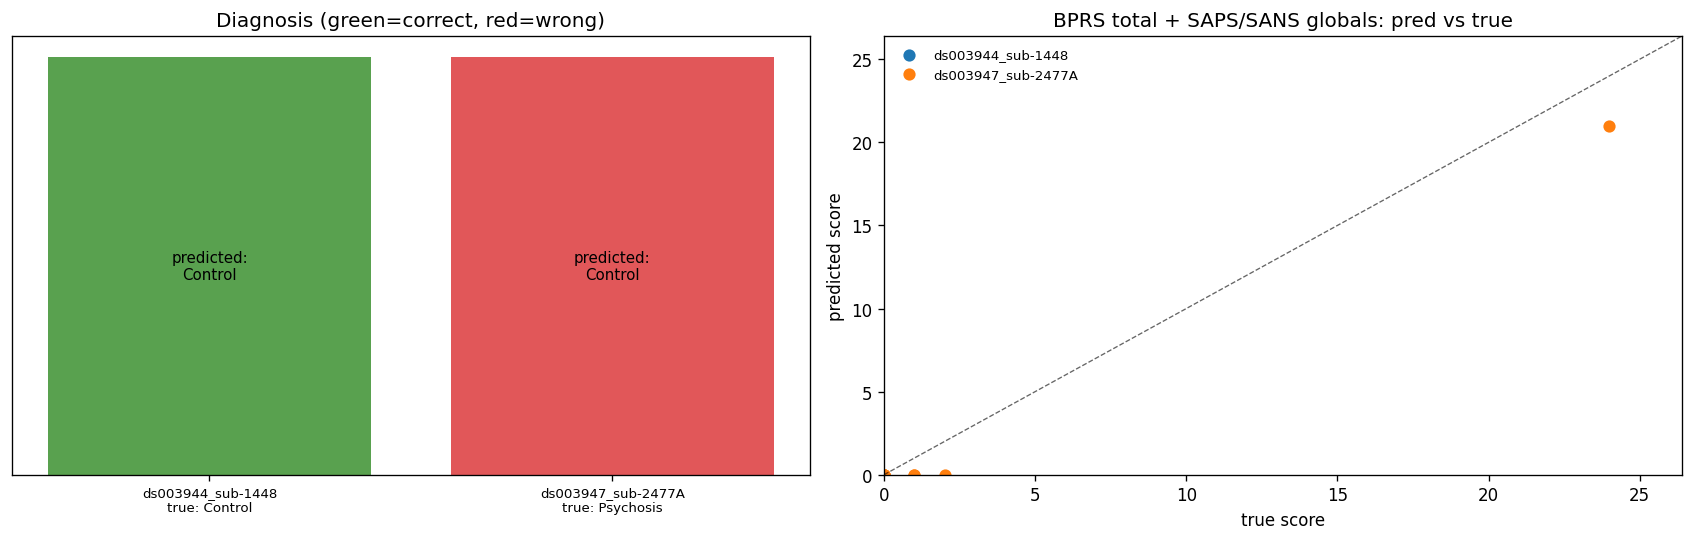

diagnosis correct: 1/2
           subject                                                              output  predicted  truth  error
 ds003944_sub-1448                                      target__bprs__total_q01_to_q19       19.0    NaN    NaN
 ds003944_sub-1448                   target__saps__q07_global_rating_of_hallucinations        0.0    NaN    NaN
 ds003944_sub-1448                        target__saps__q20_global_rating_of_delusions        0.0    NaN    NaN
 ds003944_sub-1448                 target__saps__q25_global_rating_of_bizzare_behavior        0.0    NaN    NaN
 ds003944_sub-1448 target__saps__q34_global_rating_of_positive_formal_thought_disorder        0.0    NaN    NaN
 ds003944_sub-1448             target__sans__q07_global_rating_of_affective_flattening        0.0    NaN    NaN
 ds003944_sub-1448                           target__sans__q13_global_rating_of_alogia        0.0    NaN    NaN
 ds003944_sub-1448                        target__sans__q17_global_rating_of_avol

In [7]:
rows = RUN.get("PSYCHOSIS", [])
if any(r.get("ok") for r in rows):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), constrained_layout=True)
    labels, correct = [], []
    for r in rows:
        if not r.get("ok"):
            continue
        pred = r["prediction"]["label"]; true = r["diagnosis"]
        labels.append(f"{r['subject'][:18]}\ntrue: {true}"); correct.append(pred == true)
        ax[0].annotate(f"predicted:\n{pred}", (len(labels) - 1, 0.5), ha="center", va="center", fontsize=9)
    ax[0].bar(range(len(labels)), [1] * len(labels), color=["#59a14f" if c else "#e15759" for c in correct])
    ax[0].set_xticks(range(len(labels))); ax[0].set_xticklabels(labels, fontsize=8)
    ax[0].set_yticks([]); ax[0].set_title("Diagnosis (green=correct, red=wrong)")
    df = _reg_frame(rows)
    sym = df[df["output"] != "target__psychosis__case_control_label"].copy()
    sym["name"] = sym["output"].str.split("__").str[-1].str.slice(0, 16)
    for subj in sorted(sym["subject"].unique()):
        s = sym[sym["subject"] == subj]
        ax[1].scatter(s["truth"], s["predicted"], label=subj[:18], s=40)
    lim = [0, max(1, np.nanmax(sym[["truth", "predicted"]].to_numpy()) * 1.1)]
    ax[1].plot(lim, lim, "k--", lw=0.8, alpha=0.6); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
    ax[1].set_xlabel("true score"); ax[1].set_ylabel("predicted score")
    ax[1].set_title("BPRS total + SAPS/SANS globals: pred vs true"); ax[1].legend(fontsize=8, frameon=False)
    plt.show()
    print(f"diagnosis correct: {sum(correct)}/{len(correct)}")
    print(df[["subject", "output", "predicted", "truth", "error"]].round(2).to_string(index=False))
else:
    print("Run the PSYCHOSIS subset cell above first.")

## 5. NUMERACY subset run (numeracy after stroke, OpenNeuro ds006533)

Runs 2 subjects on the per-parcel lesion tier for BOTH numeracy phenotypes, on the deepseek anchor, so
their dissociation reads on one population-Z scale. Press to run it yourself; it caches (pass `rerun=True`
to force). NOTE: the ladder was trimmed on 2026-07-23 to a single high-resolution lesion tier, so the
subset now runs on `T3_lesion_fine`; press with `rerun=True` to run on it (the displayed output is the
prior coarse-tier run).

**INPUT - data-complexity ladder** (3 tiers; subset in bold)

| tier | adds | ~tokens |
|---|---|---|
| T1_demographics | age, education, imaging modality | 22 |
| T2_aphasia | + WAB-R aphasia quotient, whole-brain lesion load | 76 |
| **T3_lesion_fine (subset, full)** | + per-parcel lesion overlap (194 features) | 3017 |

**OUTPUT - target phenotype** (two dissociable univariate phenotypes, predicted separately)
- `approximate_numeracy`: non-symbolic Approximate Number System, population Z-score
- `precise_numeracy`: precise symbolic numeracy, population Z-score

**Linguistic representation:** the global instruction states the cohort (ds006533, 105 left-hemisphere
chronic stroke survivors) and that both scores are population Z-scores centred on the stroke cohort
(0 = cohort mean).

In [8]:
RUN["NUMERACY"] = run_dataset("NUMERACY", [DATASETS["NUMERACY"]["subset_tier"]], rerun=False)

[NUMERACY] subset: 4 total runs | 4 already cached ok | 0 to run now


[NUMERACY] nothing to do; using cached results (set rerun=True to redo).


### 5.1 Approximate vs precise numeracy recovery

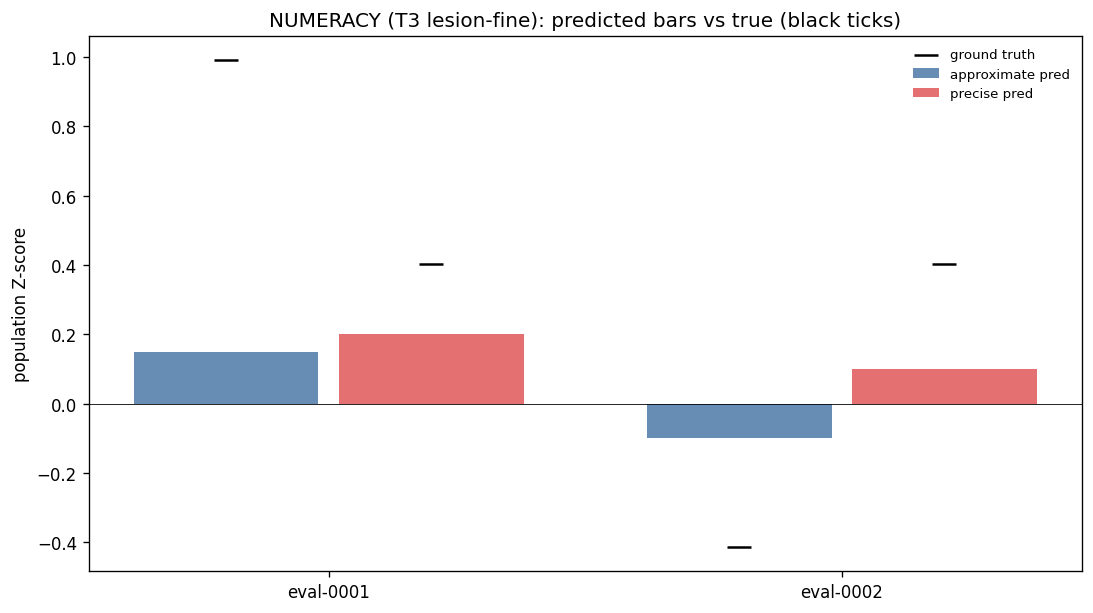

  subject               output  predicted  truth  error
eval-0001 approximate_numeracy      0.150  0.991 -0.841
eval-0002 approximate_numeracy     -0.098 -0.414  0.316
eval-0002     precise_numeracy      0.100  0.403 -0.303
eval-0001     precise_numeracy      0.200  0.403 -0.203

Mean absolute error (Z units):
output
approximate_numeracy    0.578
precise_numeracy        0.253


In [9]:
df = _reg_frame(RUN.get("NUMERACY", []))
if not df.empty:
    subjects = sorted(df["subject"].unique())
    fig, ax = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)
    x = np.arange(len(subjects)); w = 0.2
    cmap = {"approximate_numeracy": "#4e79a7", "precise_numeracy": "#e15759"}
    for j, (o, c) in enumerate(cmap.items()):
        pr = [df[(df.subject == s) & (df.output == o)]["predicted"].mean() for s in subjects]
        tr = [df[(df.subject == s) & (df.output == o)]["truth"].mean() for s in subjects]
        ax.bar(x + (j - 0.5) * w * 2, pr, w * 1.8, color=c, alpha=0.85, label=f"{o.split('_')[0]} pred")
        ax.scatter(x + (j - 0.5) * w * 2, tr, color="k", marker="_", s=200, zorder=3,
                   label="ground truth" if j == 0 else None)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(subjects); ax.set_ylabel("population Z-score")
    ax.set_title("NUMERACY (T3 lesion-fine): predicted bars vs true (black ticks)")
    ax.legend(fontsize=8, frameon=False); plt.show()
    print(df[["subject", "output", "predicted", "truth", "error"]].round(3).to_string(index=False))
    mae = df.dropna(subset=["error"]).groupby("output")["error"].apply(lambda e: e.abs().mean())
    print("\nMean absolute error (Z units):"); print(mae.round(3).to_string())
else:
    print("Run the NUMERACY subset cell above first.")

## 6. Full-batch API cost and wall-time estimate (before vs after the design)

This compares the naive full validation against the optimized one on the SAME cohorts, so the delta is
purely the design. Both start from the real per-run cost and duration measured on each dataset's subset
tier during the pre-run (baked in below as `BAKED_ANCHORS`, so the estimate reproduces even after the
system-temp cache is cleared; a fresh subset meta overrides them). From that anchor:

- **Cost** scales the measured `$/run` by each tier's input-token ratio, but sub-linearly (floored and
  capped), because a run's cost is mostly fixed overhead (system prompts, orchestration, reasoning). The
  optimized side additionally multiplies each run by its assigned provider's blended price factor.
- **BEFORE** is within-subjects on the deepseek anchor only: every subject x every tier x every task.
- **AFTER** is the seeded design from section 0.5: one tier per subject (so `1/n_tiers` the runs) with the
  five providers balanced across tiers. It is computed from the exact assignment section 7 would run.
- **Wall time** uses the flat measured seconds/run per dataset. It is quoted at 1 worker and the
  rate-limited pace; the five-host panel lets you raise the worker count (each host rate-limits
  separately), and un-throttled runs are about 2-3x faster again.

Note: the intelligence AFTER cohort is the diverse 200 subjects (up from the 100 in the very first $83
estimate), and its cost is already included. Running any full cohort still needs its all-subject
compass_inputs built first.

In [ ]:
def tier_tokens(dkey, tier):
    "Input token budget of one subject's record at a tier (0 if unavailable), read from a built subset record."
    d = DATASETS[dkey]
    for task in d["tasks"]:
        for subj in d["subjects"]:
            p = d["src_dir"](tier, subj, task["name"]) / "data_overview.json"
            if p.exists():
                return json.loads(p.read_text()).get("total_tokens", 0)
    return 0

# Per-run cost + duration measured on each dataset's SUBSET tier during the pre-run (deepseek-v4-flash).
# Baked so this estimate reproduces even if the system-temp cache was cleared; a fresh subset meta wins.
BAKED_ANCHORS = {"INTELLIGENCE": (0.0128, 811.0), "PSYCHOSIS": (0.0349, 730.0), "NUMERACY": (0.0283, 273.0)}
FLOOR, CAP = 0.6, 3.0

def _anchor(dkey):
    meta_path = SCRATCH / f"results_{dkey}_subset_meta.json"
    if meta_path.exists():
        m = json.loads(meta_path.read_text())
        if m.get("cost_per_run") and m.get("avg_seconds"):
            return float(m["cost_per_run"]), float(m["avg_seconds"])
    return BAKED_ANCHORS[dkey]

rows_before, rows_after = [], []
for dkey, d in DATASETS.items():
    cpr, avg_s = _anchor(dkey)
    anchor_tok = max(1, tier_tokens(dkey, d["subset_tier"]))
    def cost_scale(t):
        return max(FLOOR, min(CAP, tier_tokens(dkey, t) / anchor_tok))
    n_tasks, n_tiers, N = len(d["tasks"]), len(d["tiers"]), d["n_cohort"]

    # BEFORE: within-subjects, deepseek-only (every subject x every tier x every task).
    before_runs = N * n_tasks * n_tiers
    before_cost = sum(N * n_tasks * cpr * cost_scale(t) for t in d["tiers"])
    rows_before.append(dict(dataset=dkey, runs=before_runs, cost_usd=round(before_cost, 2),
                            wall_h=round(before_runs * avg_s / MAX_WORKERS / 3600, 1)))

    # AFTER: the exact seeded design (one tier per subject, providers balanced), priced per assigned provider.
    design = assign_design(d["full_cohort"], d["tiers"])
    after_runs = len(design) * n_tasks
    after_cost = sum(n_tasks * cpr * cost_scale(a["tier"]) * model_price_factor(a["model"]) for a in design)
    rows_after.append(dict(dataset=dkey, runs=after_runs, cost_usd=round(after_cost, 2),
                           wall_h=round(after_runs * avg_s / MAX_WORKERS / 3600, 1)))

before, after = pd.DataFrame(rows_before), pd.DataFrame(rows_after)
bt, br = before["cost_usd"].sum(), int(before["runs"].sum())
at, ar = after["cost_usd"].sum(), int(after["runs"].sum())
print("BEFORE  (within-subjects, deepseek-only): every subject x every tier x every task")
print(before.to_string(index=False))
print(f"  TOTAL: ${bt:.0f} over {br} runs, ~{before['wall_h'].sum():.0f} h @ {MAX_WORKERS} worker\n")
print("AFTER   (between-subjects + 5-provider panel): one tier per subject, providers balanced across tiers")
print(after.to_string(index=False))
print(f"  TOTAL: ${at:.2f} over {ar} runs, ~{after['wall_h'].sum():.0f} h @ {MAX_WORKERS} worker\n")
print(f"REDUCTION: ${bt:.0f} -> ${at:.2f}  ({100*(1-at/bt):.0f}% cheaper) | {br} -> {ar} runs "
      f"({100*(1-ar/br):.0f}% fewer) | on identical cohorts (intelligence widened to {DATASETS['INTELLIGENCE']['n_cohort']}).")
print("Wall time is at 1 worker + the rate-limited pace; the 5-host panel lets you raise workers, and "
      "un-throttled runs are ~2-3x faster again. Each full cohort still needs its compass_inputs built first.")

In [ ]:
# The exact assignment the full batch would run: each subject sits in one (tier, provider) cell. The tiers
# are balanced across subjects (optimization 2) and, within every tier, the five providers are balanced
# (optimization 1), so tier and provider are decorrelated. Reproducible from DESIGN_SEED.
for dkey, d in DATASETS.items():
    design = assign_design(d["full_cohort"], d["tiers"])
    tab = design_balance_table(design, d["tiers"])
    print(f"=== {dkey}: between-subjects tier x provider plan (n={len(design)} subjects, "
          f"{len(d['tasks'])} task(s) each) ===")
    print(tab.to_string()); print()

## 7. Full-batch runs (the optimized design, guarded, NOT run here)

Each cell runs one dataset's full cohort under the section 0.5 design: `run_full_design` builds the seeded
plan (one tier per subject via optimization 2, one balanced provider per subject via optimization 1) and
executes it, routing every run to its assigned model. They are guarded by `RUN_FULL_BATCH` so they never
fire by accident; read the section 6 estimate, set the flag to `True`, and run one dataset at a time.
Results cache to system temp under `results_<dataset>_full.json` and are resumable. `run_full_design`
automatically skips subjects whose blinded compass_inputs are not built yet and reports how many, so to
evaluate a whole cohort first build that dataset's inputs for all its subjects (see its pipeline); today
intelligence has 100 of the 200 built, so a run now would cover those 100 and report the rest as to-build.

In [ ]:
RUN_FULL_BATCH = False   # set True to actually spend on a full-cohort run under the optimized design

_dk = "INTELLIGENCE"
if RUN_FULL_BATCH:
    RUN[f"{_dk}_full"] = run_full_design(_dk, label="full")
else:
    _d = DATASETS[_dk]
    print(f"[{_dk}] full batch GUARDED (RUN_FULL_BATCH=False). With the flag True this would run:")
    print(f"  {_d['n_cohort']} subjects x {len(_d['tasks'])} task = {_d['n_cohort']*len(_d['tasks'])} runs, "
          f"one balanced tier + provider per subject across {len(_d['tiers'])} tiers (between-subjects).")
    print("  OUTPUT: total intelligence (univariate) then 3 IST subscales (multivariate). Cost: section 6.")

In [ ]:
_dk = "PSYCHOSIS"
if RUN_FULL_BATCH:
    RUN[f"{_dk}_full"] = run_full_design(_dk, label="full")
else:
    _d = DATASETS[_dk]
    print(f"[{_dk}] full batch GUARDED (RUN_FULL_BATCH=False). With the flag True this would run:")
    print(f"  {_d['n_cohort']} subjects x {len(_d['tasks'])} task = {_d['n_cohort']*len(_d['tasks'])} runs, "
          f"one balanced tier + provider per subject across {len(_d['tiers'])} tiers (between-subjects).")
    print("  OUTPUT: diagnosis (binary) -> BPRS total -> SAPS/SANS globals. Cost: section 6.")

In [ ]:
_dk = "NUMERACY"
if RUN_FULL_BATCH:
    RUN[f"{_dk}_full"] = run_full_design(_dk, label="full")
else:
    _d = DATASETS[_dk]
    print(f"[{_dk}] full batch GUARDED (RUN_FULL_BATCH=False). With the flag True this would run:")
    print(f"  {_d['n_cohort']} subjects x {len(_d['tasks'])} tasks = {_d['n_cohort']*len(_d['tasks'])} runs, "
          f"one balanced tier + provider per subject across {len(_d['tiers'])} tiers (between-subjects).")
    print("  OUTPUT: approximate + precise numeracy (two dissociable univariate phenotypes). Cost: section 6.")

## 8. Summary

In [ ]:
allrows = [r for k in ("INTELLIGENCE", "PSYCHOSIS", "NUMERACY") for r in RUN.get(k, [])]
ok = [r for r in allrows if r.get("ok")]
print(f"subset engine runs: {len(allrows)} total | {len(ok)} ok | {len(allrows)-len(ok)} errored")
if ok:
    print(f"avg run time: {np.mean([r['seconds'] for r in ok]):.0f}s | subset anchor model: {DEFAULT_MODEL}")
    frames = [_reg_frame(RUN.get(k, [])) for k in ("INTELLIGENCE", "PSYCHOSIS", "NUMERACY")]
    allreg = pd.concat([f for f in frames if not f.empty], ignore_index=True) if any(not f.empty for f in frames) else pd.DataFrame()
    if not allreg.empty:
        allreg["abserr"] = allreg["error"].abs()
        print("\nmean absolute error by output:")
        print(allreg.dropna(subset=["abserr"]).groupby("output")["abserr"].mean().round(2).to_string())
for r in [r for r in allrows if not r.get("ok")][:8]:
    print(f"  ERROR {r['dataset']} {r['tier']} {r['subject']}: {r.get('error')}")
print("\nSubset validation complete. The full validation runs the optimized design (section 0.5): a diverse "
      "200-subject intelligence cohort plus psychosis and numeracy, one tier per subject across a balanced "
      "five-provider panel, estimated near $14 in section 6 and guarded in section 7.")